<a href="https://colab.research.google.com/github/cshenoy86/machinelearning/blob/02-car-price-prediction/02_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Car Price Prediction**

This project uses the car data from Kaggle to train a machine learning model that can help predict car prices using features like year, kilometers driven, fuel type etc.

We will use


*   Car data set from Kaggle
*   Pandas for data handling
*   Numpy for numeric operations
*   Matplotlib and seaborn for data visualization
*   Scikit learn to build and evaluate the model







**1. Import Libraries**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

**2. Kaggle API + Dataset Download + Load (for Colab)**

In [26]:
# Step 1: Upload kaggle.json (only once per session)
from google.colab import files
files.upload()  # Choose your kaggle.json file from local

# Step 2: Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 3: Download the dataset (CarDekho)
!kaggle datasets download -d nehalbirla/vehicle-dataset-from-cardekho

# Step 4: Unzip the downloaded file
!unzip -o vehicle-dataset-from-cardekho.zip

# Step 5: Load the dataset
import pandas as pd

#Create a dataframe from the data
df = pd.read_csv("car data.csv")
df.head()


Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
License(s): DbCL-1.0
vehicle-dataset-from-cardekho.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  vehicle-dataset-from-cardekho.zip
  inflating: CAR DETAILS FROM CAR DEKHO.csv  
  inflating: Car details v3.csv      
  inflating: car data.csv            
  inflating: car details v4.csv      


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**3. Explore the dataset**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


<Axes: >

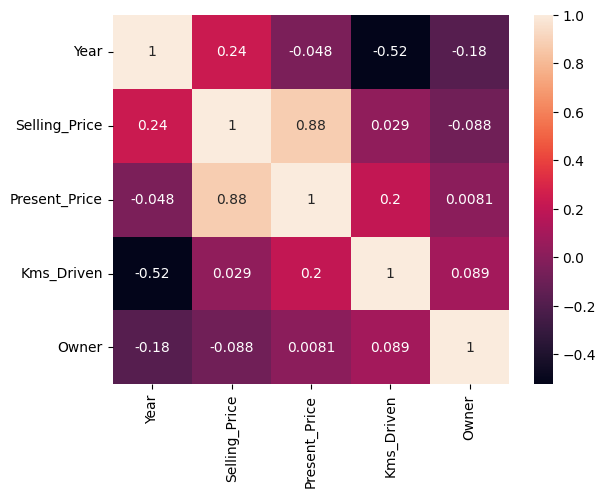

In [27]:
#print(df.info())
df.info()
#print(df.describe(percentiles=None,include='all'))
df.describe()
df.isnull().sum()

#Drop non numeric columns before calculating correlation matrix
# 🔍 Correlation Heatmap Interpretation:
# - Selling_Price has a strong positive correlation with Present_Price (0.88)
#   → Meaning: cars that cost more when new usually resell for more
# - Year has a mild positive correlation (0.24), suggesting newer cars tend to sell for more
# - Owner has a small negative correlation (-0.088), showing that cars with more owners slightly reduce resale value
# - Kms_Driven shows almost no correlation (0.029), which might be due to variation in car condition or limited impact


numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(),annot=True)

**4. Preprocess the Data**

In [28]:
#Drop the Car Name column
df = df.drop('Car_Name',axis=1)
#df.info()

#Convert categorical variables to one-hot encoding
df = pd.get_dummies(df,drop_first=True)


**5. Split into Features and Target**

In [30]:
#All columns except Selling_Price will be used as features to predict the car price
X = df.drop('Selling_Price',axis=1)
#Selling Price is the target variable that we want to predict
y = df['Selling_Price']

**6. Train Test Split**

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

**7. Train the Model**

In [32]:
# We create a Linear Regression object
model = LinearRegression()
#Train the model using X_train and y_train
model.fit(X_train,y_train)

LinearRegression()

**8. Predict and Evaluate**

In [36]:
#Use the trained model to make a prediction on the test set
y_pred = model.predict(X_test)

#Check the Mean Squared Error by comparing the test target with the predicted value
print("Mean Squared Error is",mean_squared_error(y_test,y_pred))

#Check R2 score
print("R2 score is",r2_score(y_test,y_pred))



Mean Squared Error is 3.478803970641293
R2 score is 0.8489813024897594
